# Proyecto de Análisis de Ventas

## Objetivo

El objetivo de este proyecto es realizar un proceso de exploración, limpieza y análisis de un conjunto de datos de ventas, con el fin de identificar problemas de calidad de los datos, obtener información relevante sobre el comportamiento de las ventas y generar conclusiones que puedan apoyar la toma de decisiones.

El análisis contempla las siguientes etapas:

1. Carga y exploración de los datos.
2. Identificación y tratamiento de valores faltantes.
3. Detección y eliminación de registros duplicados.
4. Limpieza y transformación de variables.
5. Análisis exploratorio de los datos.
6. Visualización de resultados.
7. Obtención de conclusiones.


In [116]:
import pandas as pd

## 1. Carga de los datos

Se carga el archivo de ventas en un DataFrame de Pandas para comenzar el proceso de exploración y análisis.


In [117]:
df = pd.read_excel("/content/Datos_Proyecto_Intermedio.xlsx")

## 2. Exploración inicial de los datos

En esta etapa se realiza una revisión general del conjunto de datos para conocer su estructura, dimensiones, tipos de variables y posibles problemas de calidad.

Se utilizan funciones de Pandas como `head()`, `shape` e `info()` para obtener una primera visión del contenido.


In [118]:
df.head()

,ID_Venta,Fecha,Sucursal,Categoría,Producto,Canal,Vendedor,Cliente_ID,Unidades,Precio_Unitario,Descuento,Costo_Unitario,Metodo_Pago,Estado_Entrega,Total_Venta
0,V-0001,2024-05-20 00:00:00,Santiago Centro,Tecnología,Notebook,Tienda,Diego Muñoz,C-1223,2,479400,20,359800,Tarjeta débito,Entregado,767040
1,V-0002,2024-10-14 00:00:00,Santiago Centro,Belleza,Secador,Online,Fernanda Díaz,C-1348,1,40800,5,23500,Transferencia,Entregado,38760
2,V-0003,2024-06-21 00:00:00,Antofagasta,Hogar,Silla,Tienda,Fernanda Díaz,C-1080,1,44700,10,27400,Transferencia,Entregado,40230
3,V-0004,2024-10-22 00:00:00,Viña del Mar,Belleza,Perfume,Tienda,Fernanda Díaz,C-1284,1,37800,5,27200,Efectivo,Cancelado,0
4,V-0005,2024-07-08 00:00:00,Viña del Mar,Oficina,Archivador,Online,Cristóbal León,C-1388,2,4300,0,2100,Transferencia,Entregado,8600


In [119]:
df.shape

(650, 15)

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID_Venta         650 non-null    object
 1   Fecha            649 non-null    object
 2   Sucursal         650 non-null    object
 3   Categoría        649 non-null    object
 4   Producto         648 non-null    object
 5   Canal            649 non-null    object
 6   Vendedor         647 non-null    object
 7   Cliente_ID       650 non-null    object
 8   Unidades         650 non-null    int64 
 9   Precio_Unitario  647 non-null    object
 10  Descuento        650 non-null    object
 11  Costo_Unitario   650 non-null    int64 
 12  Metodo_Pago      649 non-null    object
 13  Estado_Entrega   650 non-null    object
 14  Total_Venta      650 non-null    int64 
dtypes: int64(3), object(12)
memory usage: 76.3+ KB


## 3. Identificación de valores faltantes

Se revisa la presencia de valores faltantes en las diferentes variables del conjunto de datos. Esta revisión permite identificar las columnas que requieren tratamiento antes de realizar el análisis.


In [121]:
df.isnull().sum()

,0
ID_Venta,0
Fecha,1
Sucursal,0
Categoría,1
Producto,2
Canal,1
Vendedor,3
Cliente_ID,0
Unidades,0
Precio_Unitario,3


In [122]:
df[df.isnull().any(axis=1)]

,ID_Venta,Fecha,Sucursal,Categoría,Producto,Canal,Vendedor,Cliente_ID,Unidades,Precio_Unitario,Descuento,Costo_Unitario,Metodo_Pago,Estado_Entrega,Total_Venta
11,V-0012,2024-03-06 00:00:00,Viña del Mar,Belleza,Crema facial,Online,Martina Silva,C-1408,4,NaN,20,4700,Transferencia,Devuelto,0
84,V-0085,NaN,Temuco,Tecnología,Notebook,Marketplace,Cristóbal León,C-1408,4,577600,5,412800,Efectivo,Entregado,2194880
99,V-0100,2024-02-01 00:00:00,Santiago Centro,Belleza,Crema facial,Online,NaN,C-1449,3,13500,0,5400,Tarjeta débito,Entregado,40500
124,V-0125,2024-03-04 00:00:00,Concepción,Deportes,Balón,Tienda,Martina Silva,C-1201,3,NaN,5,8900,Transferencia,Entregado,49875
134,V-0135,2024-11-11 00:00:00,Concepción,Hogar,Organizador,WhatsApp,NaN,C-1377,5,14500,20,7800,Transferencia,Entregado,58000
306,V-0307,2024-07-19 00:00:00,Providencia,Hogar,NaN,WhatsApp,Felipe Torres,C-1514,2,100000,5,59400,Tarjeta crédito,Entregado,190000
309,V-0310,2024-07-11 00:00:00,Viña del Mar,Oficina,NaN,WhatsApp,Felipe Torres,C-1836,4,4000,0,2100,Transferencia,Entregado,16000
316,V-0317,2024-04-27 00:00:00,Providencia,Belleza,Plancha pelo,WhatsApp,Valentina Soto,C-1260,8,53300,10,36300,NaN,Entregado,383760
356,V-0357,2024-06-13 00:00:00,Las Condes,Belleza,Crema facial,Marketplace,Felipe Torres,C-1419,5,NaN,10,5100,Transferencia,Entregado,58050
400,V-0401,2024-04-16 00:00:00,Concepción,Belleza,Secador,Tienda,NaN,C-1384,3,37200,10,25300,Tarjeta débito,Entregado,100440


## 4. Detección y eliminación de registros duplicados

Se verifica la existencia de registros duplicados para evitar que una misma venta sea contabilizada más de una vez durante el análisis.

Se identificaron 4 registros duplicados exactos, los cuales fueron eliminados para mantener un único registro por venta.


In [123]:
df.duplicated().sum()

np.int64(4)

In [124]:
df[df.duplicated(keep=False)]

,ID_Venta,Fecha,Sucursal,Categoría,Producto,Canal,Vendedor,Cliente_ID,Unidades,Precio_Unitario,Descuento,Costo_Unitario,Metodo_Pago,Estado_Entrega,Total_Venta
33,V-0034,2024-03-09 00:00:00,Antofagasta,Tecnología,Teclado,WhatsApp,Cristóbal León,C-1918,5,23800,10,14500,Tarjeta débito,Cancelado,0
34,V-0034,2024-03-09 00:00:00,Antofagasta,Tecnología,Teclado,WhatsApp,Cristóbal León,C-1918,5,23800,10,14500,Tarjeta débito,Cancelado,0
569,V-0570,2024-02-28 00:00:00,Viña del Mar,Deportes,Botella deportiva,Tienda,Martina Silva,C-1567,2,7300,0,3600,Tarjeta crédito,Entregado,14600
570,V-0570,2024-02-28 00:00:00,Viña del Mar,Deportes,Botella deportiva,Tienda,Martina Silva,C-1567,2,7300,0,3600,Tarjeta crédito,Entregado,14600
586,V-0587,2024-10-20 00:00:00,Las Condes,Belleza,Crema facial,Online,Valentina Soto,C-1816,1,12400,15,4900,Tarjeta crédito,Entregado,10540
587,V-0587,2024-10-20 00:00:00,Las Condes,Belleza,Crema facial,Online,Valentina Soto,C-1816,1,12400,15,4900,Tarjeta crédito,Entregado,10540
616,V-0617,2024-03-04 00:00:00,Antofagasta,Hogar,Mesa,Marketplace,Valentina Soto,C-1221,3,89800,0,51400,Tarjeta crédito,Entregado,269400
617,V-0617,2024-03-04 00:00:00,Antofagasta,Hogar,Mesa,Marketplace,Valentina Soto,C-1221,3,89800,0,51400,Tarjeta crédito,Entregado,269400


In [125]:
df = df.drop_duplicates()

In [126]:
df.duplicated().sum()

np.int64(0)

In [127]:
print("Duplicados:", df.duplicated().sum())
print("Dimensiones:", df.shape)

Duplicados: 0
Dimensiones: (646, 15)


## 5. Limpieza de `Precio_Unitario`

Durante la exploración se detectó que la variable `Precio_Unitario` presentaba diferentes formatos y valores inconsistentes. La columna contenía valores numéricos, precios almacenados como texto con símbolos monetarios, valores faltantes y el registro `"precio pendiente"`.

Se realizó una revisión de los valores existentes y posteriormente se transformó la variable a formato numérico.

Para los registros con precio faltante se utilizó la información disponible en otras variables de la venta. En el caso de la venta devuelta, donde no era posible obtener el precio a partir del total, se utilizó la mediana de los precios registrados para el mismo producto.

Finalmente, se verificó que no quedaran valores nulos en la variable.


In [128]:
df["Precio_Unitario"].unique()

array([479400, 40800, 44700, 37800, 4300, 13300, 16100, 17100, 37100,
       20000, 33700, nan, 6700, 11600, 17800, 41500, 148500, 49200, 85600,
       3800, 48100, 99200, 21600, 35100, 3700, 32700, 17600, 90900, 18700,
       42000, 162700, 8100, 23800, 93800, 58800, 3500, 35200, 17000, 4700,
       18400, 3000, 2200, 57200, 59000, 12000, 29700, 3900, 41300, 87900,
       8800, 41700, 45600, 12900, 4500, 18000, 53800, 8000, 18500, 34300,
       11900, 51200, 91100, 3100, 19900, 10500, 14300, 45700, 49300,
       49800, 1, 9900, 478800, 2500, 23600, 11100, 2900, 7300, 577600,
       11500, 18900, 11400, 141000, 96500, 12300, 46500, 485000, 2400,
       98100, 52400, 24600, 2800, 13500, 12200, 11700, 3600, 106200,
       '$58.700', 40000, 8400, 83200, 38000, 31900, 581400, 19500, 14000,
       46300, 7500, 10900, 155700, 34600, 15800, 46900, 92800, 44200,
       27400, 59800, 18600, 23000, 46400, 14500, 25300, 49100, 141700,
       50100, 45500, 3300, 8300, 24300, 53100, 520800, 38400, 

In [129]:
df[df["Precio_Unitario"].isin(["$58.700", "$59.600", "precio pendiente", 9999999])]

,ID_Venta,Fecha,Sucursal,Categoría,Producto,Canal,Vendedor,Cliente_ID,Unidades,Precio_Unitario,Descuento,Costo_Unitario,Metodo_Pago,Estado_Entrega,Total_Venta
104,V-0105,2024-03-19 00:00:00,Temuco,Belleza,Plancha pelo,Marketplace,Ignacio Pérez,C-1992,1,$58.700,0,36400,Efectivo,Entregado,58700
484,V-0485,2024-11-04 00:00:00,Concepción,Tecnología,Notebook,Marketplace,Felipe Torres,C-1164,1,9999999,10,366900,Tarjeta débito,Entregado,538380
494,V-0495,2024-06-10 00:00:00,Las Condes,Deportes,Botella deportiva,WhatsApp,Fernanda Díaz,C-1137,6,precio pendiente,0,3200,Transferencia,Entregado,45600
640,V-0641,2024-06-21 00:00:00,Temuco,Belleza,Plancha pelo,WhatsApp,Camila Rojas,C-1998,2,$59.600,5,38100,Transferencia,Cancelado,0


In [130]:
df["Precio_Unitario"] = (
    df["Precio_Unitario"]
    .replace({"$58.700": 58700, "$59.600": 59600, "precio pendiente": None})
)

df["Precio_Unitario"] = pd.to_numeric(df["Precio_Unitario"], errors="coerce")

/tmp/ipykernel_8449/26647586.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"$58.700": 58700, "$59.600": 59600, "precio pendiente": None})


In [131]:
df["Precio_Unitario"].dtype

dtype('float64')

In [132]:
df["Precio_Unitario"].isnull().sum()

np.int64(4)

In [133]:
df[df["Precio_Unitario"].isnull()]

,ID_Venta,Fecha,Sucursal,Categoría,Producto,Canal,Vendedor,Cliente_ID,Unidades,Precio_Unitario,Descuento,Costo_Unitario,Metodo_Pago,Estado_Entrega,Total_Venta
11,V-0012,2024-03-06 00:00:00,Viña del Mar,Belleza,Crema facial,Online,Martina Silva,C-1408,4,NaN,20,4700,Transferencia,Devuelto,0
124,V-0125,2024-03-04 00:00:00,Concepción,Deportes,Balón,Tienda,Martina Silva,C-1201,3,NaN,5,8900,Transferencia,Entregado,49875
356,V-0357,2024-06-13 00:00:00,Las Condes,Belleza,Crema facial,Marketplace,Felipe Torres,C-1419,5,NaN,10,5100,Transferencia,Entregado,58050
494,V-0495,2024-06-10 00:00:00,Las Condes,Deportes,Botella deportiva,WhatsApp,Fernanda Díaz,C-1137,6,NaN,0,3200,Transferencia,Entregado,45600


In [134]:
df[df["Producto"].isin(["Crema facial", "Balón", "Botella deportiva"])][
    ["Producto", "Precio_Unitario"]
].sort_values("Producto")

,Producto,Precio_Unitario
643,Balón,20900.0
517,Balón,16900.0
166,Balón,18100.0
513,Balón,16800.0
332,Balón,20500.0
...,...,...
467,Crema facial,13900.0
189,Crema facial,11600.0
187,Crema facial,12000.0
171,Crema facial,12000.0


In [135]:
df[df["Producto"] == "Crema facial"]["Precio_Unitario"].median()

12350.0

In [136]:
df.loc[11, "Precio_Unitario"] = 12350
df.loc[124, "Precio_Unitario"] = 17500
df.loc[356, "Precio_Unitario"] = 12900
df.loc[494, "Precio_Unitario"] = 7600

In [137]:
df["Precio_Unitario"].isnull().sum()

np.int64(0)

## 6. Limpieza y transformación de la variable `Fecha`

Se revisa la variable `Fecha` para identificar su formato actual, valores faltantes o posibles inconsistencias. Posteriormente, se transformará a un formato de fecha adecuado para facilitar el análisis temporal de las ventas.


In [138]:
df["Fecha"].unique()

array([datetime.datetime(2024, 5, 20, 0, 0),
       datetime.datetime(2024, 10, 14, 0, 0),
       datetime.datetime(2024, 6, 21, 0, 0),
       datetime.datetime(2024, 10, 22, 0, 0),
       datetime.datetime(2024, 7, 8, 0, 0),
       datetime.datetime(2024, 12, 16, 0, 0),
       datetime.datetime(2024, 7, 21, 0, 0),
       datetime.datetime(2024, 2, 16, 0, 0),
       datetime.datetime(2024, 10, 10, 0, 0),
       datetime.datetime(2024, 5, 14, 0, 0),
       datetime.datetime(2024, 11, 2, 0, 0),
       datetime.datetime(2024, 3, 6, 0, 0),
       datetime.datetime(2024, 3, 2, 0, 0),
       datetime.datetime(2024, 2, 6, 0, 0),
       datetime.datetime(2024, 2, 19, 0, 0),
       datetime.datetime(2024, 4, 7, 0, 0),
       datetime.datetime(2024, 3, 26, 0, 0),
       datetime.datetime(2024, 3, 20, 0, 0),
       datetime.datetime(2024, 2, 11, 0, 0),
       datetime.datetime(2024, 12, 8, 0, 0),
       datetime.datetime(2024, 3, 8, 0, 0),
       datetime.datetime(2024, 2, 29, 0, 0),
       datet

In [139]:
df[df["Fecha"].astype(str).isin(["nan", "sin fecha", "31/02/2024", "15-15-2024", "2024-13-05"])]

,ID_Venta,Fecha,Sucursal,Categoría,Producto,Canal,Vendedor,Cliente_ID,Unidades,Precio_Unitario,Descuento,Costo_Unitario,Metodo_Pago,Estado_Entrega,Total_Venta
84,V-0085,NaN,Temuco,Tecnología,Notebook,Marketplace,Cristóbal León,C-1408,4,577600.0,5,412800,Efectivo,Entregado,2194880
223,V-0224,31/02/2024,Las Condes,Tecnología,Teclado,Tienda,Camila Rojas,C-1063,3,23000.0,0,12000,Tarjeta débito,Pendiente,69000
230,V-0231,31/02/2024,Las Condes,Hogar,Silla,Online,Cristóbal León,C-1555,2,49600.0,0,27400,Transferencia,Entregado,99200
370,V-0371,sin fecha,Concepción,Deportes,Botella deportiva,WhatsApp,Felipe Torres,C-1701,3,7900.0,20,3900,Tarjeta crédito,Entregado,18960
444,V-0445,15-15-2024,Temuco,Hogar,Organizador,Online,Camila Rojas,C-1900,4,15700.0,0,8000,Efectivo,Entregado,62800
594,V-0595,2024-13-05,La Serena,Hogar,Organizador,Marketplace,Fernanda Díaz,C-1651,1,13800.0,5,8800,Tarjeta débito,Entregado,13110


In [140]:
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

In [141]:
df["Fecha"].isnull().sum()

np.int64(6)

### Tratamiento de fechas inválidas

Se identificaron 6 registros con fechas faltantes o inválidas, los cuales fueron convertidos a `NaT` mediante `pd.to_datetime(errors="coerce")`.

Dado que no existe información suficiente para recuperar las fechas originales, estos registros se conservarán en el dataset y se excluirán únicamente de los análisis temporales.

**Impacto:** 6 registros, equivalentes al 0,93% del dataset, con ventas asociadas por $2.457.950.


In [142]:
df[df["Fecha"].isnull()][["ID_Venta", "Fecha", "Total_Venta", "Estado_Entrega"]]

,ID_Venta,Fecha,Total_Venta,Estado_Entrega
84,V-0085,NaT,2194880,Entregado
223,V-0224,NaT,69000,Pendiente
230,V-0231,NaT,99200,Entregado
370,V-0371,NaT,18960,Entregado
444,V-0445,NaT,62800,Entregado
594,V-0595,NaT,13110,Entregado


In [143]:
df[df["Fecha"].isnull()]["Total_Venta"].sum()

np.int64(2457950)

In [144]:
df["Fecha"].dtype

dtype('<M8[ns]')

## 7. Identificación de valores faltantes en variables categóricas

Se revisarán las variables categóricas para identificar registros con información faltante y determinar el tratamiento más adecuado para cada caso.


In [145]:
df[df[["Categoría", "Producto", "Canal", "Vendedor", "Metodo_Pago"]].isnull().any(axis=1)]

,ID_Venta,Fecha,Sucursal,Categoría,Producto,Canal,Vendedor,Cliente_ID,Unidades,Precio_Unitario,Descuento,Costo_Unitario,Metodo_Pago,Estado_Entrega,Total_Venta
99,V-0100,2024-02-01,Santiago Centro,Belleza,Crema facial,Online,NaN,C-1449,3,13500.0,0,5400,Tarjeta débito,Entregado,40500
134,V-0135,2024-11-11,Concepción,Hogar,Organizador,WhatsApp,NaN,C-1377,5,14500.0,20,7800,Transferencia,Entregado,58000
306,V-0307,2024-07-19,Providencia,Hogar,NaN,WhatsApp,Felipe Torres,C-1514,2,100000.0,5,59400,Tarjeta crédito,Entregado,190000
309,V-0310,2024-07-11,Viña del Mar,Oficina,NaN,WhatsApp,Felipe Torres,C-1836,4,4000.0,0,2100,Transferencia,Entregado,16000
316,V-0317,2024-04-27,Providencia,Belleza,Plancha pelo,WhatsApp,Valentina Soto,C-1260,8,53300.0,10,36300,NaN,Entregado,383760
400,V-0401,2024-04-16,Concepción,Belleza,Secador,Tienda,NaN,C-1384,3,37200.0,10,25300,Tarjeta débito,Entregado,100440
455,V-0456,2024-09-15,Providencia,Tecnología,Teclado,NaN,Fernanda Díaz,C-1972,1,22900.0,0,13100,Tarjeta débito,Entregado,22900
631,V-0632,2024-07-10,Providencia,NaN,Botella deportiva,WhatsApp,Valentina Soto,C-1198,2,7300.0,0,3900,Efectivo,Entregado,14600


In [146]:
for columna in ["Categoría", "Producto", "Canal", "Vendedor", "Metodo_Pago"]:
    print(f"\n--- {columna} ---")
    print(df.groupby(columna, dropna=False)["Total_Venta"].count().sort_values(ascending=False).head(10))


--- Categoría ---
Categoría
Hogar         134
Belleza       131
Tecnología    129
Deportes      127
Oficina       117
BELLEZA         4
Deporte         1
Oficna          1
Tecno           1
NaN             1
Name: Total_Venta, dtype: int64

--- Producto ---
Producto
Botella deportiva    44
Plancha pelo         40
Silla                39
Set lápices          37
Lámpara              36
Crema facial         36
Organizador          32
Notebook             31
Secador              30
Balón                30
Name: Total_Venta, dtype: int64

--- Canal ---
Canal
Tienda          180
Online          160
WhatsApp        154
Marketplace     141
TIENDA            3
Market place      2
On line           2
Whatsapp          2
online            1
NaN               1
Name: Total_Venta, dtype: int64

--- Vendedor ---
Vendedor
Cristóbal León    98
Fernanda Díaz     98
Felipe Torres     82
Diego Muñoz       81
Camila Rojas      77
Ignacio Pérez     70
Valentina Soto    70
Martina Silva     67
NaN         

In [147]:
df["Categoría"] = df["Categoría"].replace({
    "BELLEZA": "Belleza",
    "Deporte": "Deportes",
    "Oficna": "Oficina",
    "Tecno": "Tecnología"
})

df["Canal"] = df["Canal"].replace({
    "TIENDA": "Tienda",
    "Market place": "Marketplace",
    "On line": "Online",
    "Whatsapp": "WhatsApp",
    "online": "Online"
})

df["Producto"] = df["Producto"].replace({
    "mancuernas": "Mancuernas",
    "balón": "Balón",
    "TECLADO": "Teclado",
    "MANCUERNAS": "Mancuernas",
    "notebook": "Notebook",
    "colchoneta": "Colchoneta",
    "botella deportiva": "Botella deportiva",
    "MONITOR": "Monitor"
})

In [148]:
df["Producto"].value_counts(dropna=False)

,count
Producto,
Botella deportiva,45
Plancha pelo,40
Silla,39
Set lápices,37
Lámpara,36
Crema facial,36
Organizador,32
Notebook,32
Mancuernas,31


In [149]:
print(df["Categoría"].value_counts(dropna=False))
print("\n", df["Canal"].value_counts(dropna=False))

Categoría
Belleza       135
Hogar         134
Tecnología    130
Deportes      128
Oficina       118
NaN             1
Name: count, dtype: int64

 Canal
Tienda         183
Online         163
WhatsApp       156
Marketplace    143
NaN              1
Name: count, dtype: int64


In [150]:
df[df["Producto"] == "Botella deportiva"][["Producto", "Categoría"]].value_counts(dropna=False)

Producto           Categoría
Botella deportiva  Deportes     44
                   NaN           1
Name: count, dtype: int64

In [151]:
df.loc[df["Producto"] == "Botella deportiva", "Categoría"] = "Deportes"

In [152]:
df["Categoría"].isnull().sum()

np.int64(0)

In [153]:
df[df["Producto"].isin(["Organizador", "Teclado"])][
    ["Producto", "Sucursal", "Vendedor", "Canal"]
].value_counts(dropna=False)

Producto     Sucursal         Vendedor        Canal      
Teclado      Las Condes       Cristóbal León  Marketplace    2
             La Serena        Diego Muñoz     Online         2
Organizador  Antofagasta      Fernanda Díaz   Online         1
             Concepción       Felipe Torres   Online         1
                                              Tienda         1
                              Fernanda Díaz   WhatsApp       1
                              NaN             WhatsApp       1
             La Serena        Camila Rojas    Tienda         1
             Antofagasta      Diego Muñoz     Tienda         1
                              Felipe Torres   Marketplace    1
             Las Condes       Camila Rojas    Online         1
                                              Tienda         1
                              Cristóbal León  Marketplace    1
                                              Tienda         1
                              Fernanda Díaz   Marketplace    1
             Providencia      Diego Muñoz     Online         1
                                              Tienda         1
                              Felipe Torres   Tienda         1
                              Fernanda Díaz   Marketplace    1
                              Valentina Soto  Marketplace    1
             Santiago Centro  Camila Rojas    Online         1
                              Cristóbal León  Online         1
                              Diego Muñoz     Online         1
                              Felipe Torres   WhatsApp       1
             La Serena        Cristóbal León  WhatsApp       1
                              Fernanda Díaz   Marketplace    1
             Temuco           Camila Rojas    Tienda         1
                                              Online         1
                              Ignacio Pérez   WhatsApp       1
                              Felipe Torres   Marketplace    1
             Viña del Mar     Felipe Torres   Online         1
                              Martina Silva   Tienda         1
Teclado      Antofagasta      Camila Rojas    WhatsApp       1
Organizador  Temuco           Fernanda Díaz   Tienda         1
Teclado      Antofagasta      Cristóbal León  WhatsApp       1
                              Fernanda Díaz   WhatsApp       1
             Concepción       Felipe Torres   Tienda         1
                              Cristóbal León  Tienda         1
             La Serena        Camila Rojas    Online         1
                              Cristóbal León  Marketplace    1
                              Fernanda Díaz   Online         1
Organizador  Viña del Mar     Camila Rojas    Online         1
Teclado      Las Condes       Camila Rojas    Tienda         1
             Providencia      Fernanda Díaz   NaN            1
             Santiago Centro  Camila Rojas    Marketplace    1
                                              Tienda         1
                              Cristóbal León  Online         1
                              Felipe Torres   Tienda         1
                              Valentina Soto  Tienda         1
             Temuco           Diego Muñoz     Tienda         1
                              Felipe Torres   Marketplace    1
                                              WhatsApp       1
                              Fernanda Díaz   Online         1
             Viña del Mar     Cristóbal León  Tienda         1
                              Diego Muñoz     Marketplace    1
                              Felipe Torres   WhatsApp       1
                              Ignacio Pérez   Online         1
                                              Tienda         1
Name: count, dtype: int64

In [154]:
df[df["Vendedor"].isnull()][
    ["ID_Venta", "Sucursal", "Categoría", "Producto", "Canal", "Cliente_ID"]
]

,ID_Venta,Sucursal,Categoría,Producto,Canal,Cliente_ID
99,V-0100,Santiago Centro,Belleza,Crema facial,Online,C-1449
134,V-0135,Concepción,Hogar,Organizador,WhatsApp,C-1377
400,V-0401,Concepción,Belleza,Secador,Tienda,C-1384


In [155]:
df[
    (df["Producto"].isin(["Crema facial", "Organizador", "Secador"])) &
    (df["Sucursal"].isin(["Santiago Centro", "Concepción"])) &
    (df["Canal"].isin(["Online", "WhatsApp", "Tienda"]))
][["Sucursal", "Producto", "Canal", "Vendedor"]].value_counts(dropna=False)

Sucursal         Producto      Canal     Vendedor      
Concepción       Secador       WhatsApp  Cristóbal León    2
                 Crema facial  Online    Valentina Soto    1
                 Organizador   Online    Felipe Torres     1
                               Tienda    Felipe Torres     1
                               WhatsApp  NaN               1
                                         Fernanda Díaz     1
                 Secador       Tienda    Ignacio Pérez     1
                                         NaN               1
                               WhatsApp  Fernanda Díaz     1
Santiago Centro  Crema facial  Online    NaN               1
                               Tienda    Fernanda Díaz     1
                 Organizador   Online    Camila Rojas      1
                                         Cristóbal León    1
                                         Diego Muñoz       1
                               WhatsApp  Felipe Torres     1
                 Secador       Online    Fernanda Díaz     1
                               WhatsApp  Camila Rojas      1
                                         Fernanda Díaz     1
Name: count, dtype: int64

In [156]:
df[df["ID_Venta"] == "V-0317"][
    ["Producto", "Canal", "Vendedor", "Metodo_Pago"]
]

,Producto,Canal,Vendedor,Metodo_Pago
316,Plancha pelo,WhatsApp,Valentina Soto,NaN


In [157]:
df[(df["Producto"] == "Plancha pelo") & (df["Canal"] == "WhatsApp")][
    ["Producto", "Canal", "Vendedor", "Metodo_Pago"]
].value_counts(dropna=False)

Producto      Canal     Vendedor        Metodo_Pago   
Plancha pelo  WhatsApp  Camila Rojas    Transferencia     2
                        Cristóbal León  Transferencia     2
                        Diego Muñoz     Tarjeta débito    1
                        Felipe Torres   Efectivo          1
                                        Transferencia     1
                        Fernanda Díaz   Efectivo          1
                        Ignacio Pérez   Tarjeta débito    1
                        Valentina Soto  Tarjeta débito    1
                                        NaN               1
Name: count, dtype: int64

In [158]:
df[df["Producto"].isnull()][
    ["ID_Venta", "Categoría", "Canal", "Vendedor", "Cliente_ID"]
]

,ID_Venta,Categoría,Canal,Vendedor,Cliente_ID
306,V-0307,Hogar,WhatsApp,Felipe Torres,C-1514
309,V-0310,Oficina,WhatsApp,Felipe Torres,C-1836


In [159]:
df.isnull().sum()

,0
ID_Venta,0
Fecha,6
Sucursal,0
Categoría,0
Producto,2
Canal,1
Vendedor,3
Cliente_ID,0
Unidades,0
Precio_Unitario,0


In [160]:
df["Categoría"] = df["Categoría"].fillna("Sin categoría")
df["Producto"] = df["Producto"].fillna("Sin producto")
df["Canal"] = df["Canal"].fillna("Sin canal")
df["Vendedor"] = df["Vendedor"].fillna("Sin vendedor")
df["Metodo_Pago"] = df["Metodo_Pago"].fillna("Sin método de pago")

In [161]:
df.isnull().sum()

,0
ID_Venta,0
Fecha,6
Sucursal,0
Categoría,0
Producto,0
Canal,0
Vendedor,0
Cliente_ID,0
Unidades,0
Precio_Unitario,0


### Tratamiento de valores faltantes

Luego de la revisión y limpieza, las variables categóricas quedaron sin valores faltantes. Los registros que no contaban con información suficiente para realizar una imputación confiable fueron clasificados como **`"Desconocido"`**, evitando introducir información no respaldada por los datos.

La variable `Fecha` mantiene **6 registros como `NaT`**, correspondientes a fechas faltantes o inválidas que no pudieron ser recuperadas.

Con esto, finaliza la etapa de tratamiento de valores faltantes.


In [162]:
df["Precio_Unitario"].describe()

,Precio_Unitario
count,6.460000e+02
mean,7.198259e+04
std,4.067547e+05
min,1.000000e+00
25%,1.132500e+04
50%,1.890000e+04
75%,4.775000e+04
max,9.999999e+06


In [163]:
df.nlargest(10, "Precio_Unitario")[[
    "ID_Venta",
    "Producto",
    "Unidades",
    "Precio_Unitario",
    "Descuento",
    "Total_Venta"
]]

,ID_Venta,Producto,Unidades,Precio_Unitario,Descuento,Total_Venta
484,V-0485,Notebook,1,9999999.0,10,538380
476,V-0477,Notebook,3,609000.0,10,1644300
583,V-0584,Notebook,2,596500.0,0,1193000
165,V-0166,Notebook,2,589000.0,0,1178000
240,V-0241,Notebook,3,588600.0,10,1589220
296,V-0297,Notebook,1,581500.0,5,0
110,V-0111,Notebook,2,581400.0,0,1162800
84,V-0085,Notebook,4,577600.0,5,2194880
621,V-0622,Notebook,-1,577300.0,0,1154600
615,V-0616,Notebook,4,568900.0,15,1934260


In [164]:
df[df["ID_Venta"].isin(["V-0485", "V-0297", "V-0622"])][[
    "ID_Venta",
    "Producto",
    "Unidades",
    "Precio_Unitario",
    "Descuento",
    "Total_Venta",
    "Estado_Entrega"
]]

,ID_Venta,Producto,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
296,V-0297,Notebook,1,581500.0,5,0,Devuelto
484,V-0485,Notebook,1,9999999.0,10,538380,Entregado
621,V-0622,Notebook,-1,577300.0,0,1154600,Entregado


In [165]:
df[df["Unidades"] < 0][[
    "ID_Venta",
    "Producto",
    "Unidades",
    "Precio_Unitario",
    "Descuento",
    "Total_Venta",
    "Estado_Entrega"
]]

,ID_Venta,Producto,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
140,V-0141,Set lápices,-3,3300.0,20,5280,Entregado
391,V-0392,Botella deportiva,-1,8000.0,20,6400,Entregado
432,V-0433,Secador,-3,34400.0,10,247680,Entregado
468,V-0469,Set lápices,-1,3500.0,0,31500,Pendiente
527,V-0528,Botella deportiva,-1,7200.0,10,0,Cancelado
621,V-0622,Notebook,-1,577300.0,0,1154600,Entregado


In [166]:
df["Descuento"].value_counts(dropna=False)

,count
Descuento,
0,212
5,153
10,123
15,85
20,65
10%,3
80,2
-5,2
55,1


In [167]:
df[df["Descuento"].isin([80, -5, 55])][[
    "ID_Venta",
    "Producto",
    "Unidades",
    "Precio_Unitario",
    "Descuento",
    "Total_Venta",
    "Estado_Entrega"
]]

,ID_Venta,Producto,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
246,V-0247,Plancha pelo,2,50100.0,80,100200,Pendiente
298,V-0299,Calculadora,1,12200.0,-5,10980,Pendiente
401,V-0402,Plancha pelo,4,59200.0,-5,213120,Entregado
627,V-0628,Silla,3,45400.0,55,136200,Entregado
634,V-0635,Balón,7,20600.0,80,129780,Entregado


In [168]:
df["Descuento"].unique()

array([20, 5, 10, 0, 15, '10%', 80, -5, 55], dtype=object)

In [169]:
df["Descuento"] = df["Descuento"].replace("10%", 10)
df["Descuento"] = pd.to_numeric(df["Descuento"])

/tmp/ipykernel_8449/2926531479.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Descuento"] = df["Descuento"].replace("10%", 10)


In [170]:
df["Descuento"].unique()

array([20,  5, 10,  0, 15, 80, -5, 55])

In [171]:
df.groupby("Producto")["Descuento"].unique()

,Descuento
Producto,
Archivador,"[0, 5, 15, 10, 20]"
Balón,"[0, 5, 10, 20, 15, 80]"
Botella deportiva,"[20, 0, 5, 15, 10]"
Calculadora,"[15, 0, 5, 10, -5]"
Colchoneta,"[15, 10, 20, 5, 0]"
Crema facial,"[0, 20, 5, 10, 15]"
Cuaderno,"[15, 10, 20, 0, 5]"
Impresora,"[5, 10, 0, 15]"
Lámpara,"[0, 5, 10, 20, 15]"


In [172]:
df["Descuento_Anomalo"] = ~df["Descuento"].isin([0, 5, 10, 15, 20])

In [173]:
df["Descuento_Anomalo"].value_counts()

,count
Descuento_Anomalo,
False,641
True,5


In [174]:
df.loc[df["Descuento_Anomalo"], [
    "ID_Venta", "Producto", "Unidades",
    "Precio_Unitario", "Descuento", "Total_Venta",
    "Estado_Entrega"
]]

,ID_Venta,Producto,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
246,V-0247,Plancha pelo,2,50100.0,80,100200,Pendiente
298,V-0299,Calculadora,1,12200.0,-5,10980,Pendiente
401,V-0402,Plancha pelo,4,59200.0,-5,213120,Entregado
627,V-0628,Silla,3,45400.0,55,136200,Entregado
634,V-0635,Balón,7,20600.0,80,129780,Entregado


In [175]:
df["Descuento_Calculado"] = (
    1 - (df["Total_Venta"] / (df["Unidades"].abs() * df["Precio_Unitario"]))
) * 100

df.loc[df["Descuento_Anomalo"], [
    "ID_Venta", "Descuento", "Descuento_Calculado", "Total_Venta"
]]

,ID_Venta,Descuento,Descuento_Calculado,Total_Venta
246,V-0247,80,0.0,100200
298,V-0299,-5,10.0,10980
401,V-0402,-5,10.0,213120
627,V-0628,55,0.0,136200
634,V-0635,80,10.0,129780


In [176]:
df.loc[df["ID_Venta"].isin(["V-0247", "V-0299", "V-0402", "V-0628", "V-0635"]), "Descuento"] = [
    0, 10, 10, 0, 10
]

In [177]:
df["Descuento_Anomalo"] = ~df["Descuento"].isin([0, 5, 10, 15, 20])
df["Descuento_Anomalo"].value_counts()

,count
Descuento_Anomalo,
False,646


In [178]:
df = df.drop(columns=["Descuento_Anomalo", "Descuento_Calculado"])

In [179]:
df.loc[df["ID_Venta"] == "V-0485", [
    "ID_Venta", "Producto", "Unidades",
    "Precio_Unitario", "Descuento", "Total_Venta"
]]

,ID_Venta,Producto,Unidades,Precio_Unitario,Descuento,Total_Venta
484,V-0485,Notebook,1,9999999.0,10,538380


In [180]:
df.loc[df["ID_Venta"] == "V-0485", "Precio_Unitario"] = 598200

In [181]:
df.loc[df["ID_Venta"] == "V-0485", [
    "ID_Venta", "Producto", "Unidades",
    "Precio_Unitario", "Descuento", "Total_Venta"
]]

,ID_Venta,Producto,Unidades,Precio_Unitario,Descuento,Total_Venta
484,V-0485,Notebook,1,598200.0,10,538380


In [182]:
ids_originalmente_vacios = [
    "V-0085",  # Fecha originalmente vacía
    "V-0012",  # Precio_Unitario originalmente vacío
    "V-0125",  # Precio_Unitario originalmente vacío
    "V-0357",  # Precio_Unitario originalmente vacío
    "V-0100",  # Vendedor originalmente vacío
    "V-0135",  # Vendedor originalmente vacío
    "V-0307",  # Producto originalmente vacío
    "V-0310",  # Producto originalmente vacío
    "V-0317",  # Metodo_Pago originalmente vacío
    "V-0401",  # Vendedor originalmente vacío
    "V-0456",  # Canal originalmente vacío
    "V-0632"   # Categoría originalmente vacía
]

df["Dato_Originalmente_Vacio"] = df["ID_Venta"].isin(ids_originalmente_vacios)

In [183]:
df["Dato_Originalmente_Vacio"].value_counts()

,count
Dato_Originalmente_Vacio,
False,634
True,12


In [184]:
df.nlargest(10, "Precio_Unitario")[[
    "ID_Venta", "Producto", "Unidades",
    "Precio_Unitario", "Descuento", "Total_Venta",
    "Estado_Entrega"
]]

,ID_Venta,Producto,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
476,V-0477,Notebook,3,609000.0,10,1644300,Entregado
484,V-0485,Notebook,1,598200.0,10,538380,Entregado
583,V-0584,Notebook,2,596500.0,0,1193000,Entregado
165,V-0166,Notebook,2,589000.0,0,1178000,Entregado
240,V-0241,Notebook,3,588600.0,10,1589220,Entregado
296,V-0297,Notebook,1,581500.0,5,0,Devuelto
110,V-0111,Notebook,2,581400.0,0,1162800,Pendiente
84,V-0085,Notebook,4,577600.0,5,2194880,Entregado
621,V-0622,Notebook,-1,577300.0,0,1154600,Entregado
615,V-0616,Notebook,4,568900.0,15,1934260,Pendiente


In [185]:
df.nsmallest(10, "Precio_Unitario")[[
    "ID_Venta", "Producto", "Unidades",
    "Precio_Unitario", "Descuento", "Total_Venta",
    "Estado_Entrega"
]]

,ID_Venta,Producto,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
73,V-0074,Lámpara,2,1.0,20,0,Devuelto
341,V-0342,Set lápices,1,1.0,0,3300,Entregado
364,V-0365,Mesa,5,1.0,20,418800,Entregado
406,V-0407,Mouse,1,1.0,20,8800,Entregado
499,V-0500,Set lápices,2,1.0,0,6800,Entregado
561,V-0562,Organizador,8,1.0,0,116800,Pendiente
591,V-0592,Organizador,6,1.0,10,71280,Entregado
43,V-0044,Cuaderno,4,2200.0,15,7480,Entregado
151,V-0152,Cuaderno,2,2200.0,10,4400,Entregado
477,V-0478,Cuaderno,1,2200.0,0,2200,Entregado


In [186]:
df[df["Precio_Unitario"] == 1][[
    "ID_Venta", "Producto", "Unidades",
    "Precio_Unitario", "Descuento",
    "Total_Venta", "Estado_Entrega"
]]

,ID_Venta,Producto,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
73,V-0074,Lámpara,2,1.0,20,0,Devuelto
341,V-0342,Set lápices,1,1.0,0,3300,Entregado
364,V-0365,Mesa,5,1.0,20,418800,Entregado
406,V-0407,Mouse,1,1.0,20,8800,Entregado
499,V-0500,Set lápices,2,1.0,0,6800,Entregado
561,V-0562,Organizador,8,1.0,0,116800,Pendiente
591,V-0592,Organizador,6,1.0,10,71280,Entregado


In [187]:
df[df["Producto"] == "Lámpara"][[
    "ID_Venta", "Unidades", "Precio_Unitario",
    "Descuento", "Total_Venta", "Estado_Entrega"
]].sort_values("Precio_Unitario")

,ID_Venta,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
73,V-0074,2,1.0,20,0,Devuelto
390,V-0391,5,15900.0,15,67575,Entregado
620,V-0621,2,15900.0,0,31800,Entregado
537,V-0538,1,15900.0,0,15900,Entregado
308,V-0309,2,16100.0,10,28980,Entregado
435,V-0436,5,16400.0,5,77900,Pendiente
266,V-0267,3,16500.0,0,49500,Entregado
623,V-0624,5,16500.0,10,74250,Pendiente
521,V-0522,1,16800.0,10,0,Devuelto
39,V-0040,2,17000.0,10,30600,Entregado


In [188]:
df.loc[
    (df["Producto"] == "Lámpara") & (df["Precio_Unitario"] != 1),
    "Precio_Unitario"
].median()

18000.0

In [189]:
id_precios_corregir = {
    "V-0074": 18000,
    "V-0342": 3300,
    "V-0365": 104700,
    "V-0407": 11000,
    "V-0500": 3400,
    "V-0562": 14600,
    "V-0592": 13200
}

for venta, precio in id_precios_corregir.items():
    df.loc[df["ID_Venta"] == venta, "Precio_Unitario"] = precio

In [190]:
df[df["ID_Venta"].isin(id_precios_corregir.keys())][[
    "ID_Venta", "Producto", "Unidades",
    "Precio_Unitario", "Descuento",
    "Total_Venta", "Estado_Entrega"
]].sort_values("ID_Venta")

,ID_Venta,Producto,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
73,V-0074,Lámpara,2,18000.0,20,0,Devuelto
341,V-0342,Set lápices,1,3300.0,0,3300,Entregado
364,V-0365,Mesa,5,104700.0,20,418800,Entregado
406,V-0407,Mouse,1,11000.0,20,8800,Entregado
499,V-0500,Set lápices,2,3400.0,0,6800,Entregado
561,V-0562,Organizador,8,14600.0,0,116800,Pendiente
591,V-0592,Organizador,6,13200.0,10,71280,Entregado


In [191]:
df[df["Unidades"] < 0][[
    "ID_Venta", "Producto", "Unidades",
    "Precio_Unitario", "Descuento",
    "Total_Venta", "Estado_Entrega"
]]

,ID_Venta,Producto,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
140,V-0141,Set lápices,-3,3300.0,20,5280,Entregado
391,V-0392,Botella deportiva,-1,8000.0,20,6400,Entregado
432,V-0433,Secador,-3,34400.0,10,247680,Entregado
468,V-0469,Set lápices,-1,3500.0,0,31500,Pendiente
527,V-0528,Botella deportiva,-1,7200.0,10,0,Cancelado
621,V-0622,Notebook,-1,577300.0,0,1154600,Entregado


In [192]:
df[df["Producto"] == "Set lápices"][[
    "ID_Venta", "Unidades", "Precio_Unitario",
    "Descuento", "Total_Venta", "Estado_Entrega"
]].sort_values("Unidades")

,ID_Venta,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
140,V-0141,-3,3300.0,20,5280,Entregado
468,V-0469,-1,3500.0,0,31500,Pendiente
220,V-0221,0,3100.0,5,17670,Entregado
162,V-0163,1,3800.0,10,0,Devuelto
318,V-0319,1,3200.0,5,0,Devuelto
341,V-0342,1,3300.0,0,3300,Entregado
284,V-0285,1,3400.0,20,2720,Entregado
66,V-0067,1,3100.0,20,2480,Entregado
402,V-0403,1,3100.0,0,3100,Pendiente
541,V-0542,1,3400.0,15,2890,Entregado


In [193]:
df[df["Producto"] == "Botella deportiva"][[
    "ID_Venta", "Unidades", "Precio_Unitario",
    "Descuento", "Total_Venta", "Estado_Entrega"
]].sort_values("Unidades")

,ID_Venta,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
391,V-0392,-1,8000.0,20,6400,Entregado
527,V-0528,-1,7200.0,10,0,Cancelado
263,V-0264,1,7000.0,0,0,Devuelto
60,V-0061,1,8000.0,0,56615,Devuelto
322,V-0323,1,8100.0,5,7695,Entregado
344,V-0345,1,7600.0,5,7220,Pendiente
310,V-0311,1,8600.0,5,8170,Entregado
175,V-0176,1,7400.0,10,0,Devuelto
440,V-0441,1,6700.0,0,6700,Entregado
472,V-0473,1,8200.0,10,7380,Entregado


In [194]:
df["Total_Calculado"] = (
    df["Unidades"].abs()
    * df["Precio_Unitario"]
    * (1 - df["Descuento"] / 100)
).round(2)

df["Diferencia"] = (
    df["Total_Venta"] - df["Total_Calculado"]
).round(2)

df[df["Diferencia"].abs() > 1][[
    "ID_Venta", "Unidades", "Precio_Unitario",
    "Descuento", "Total_Venta",
    "Total_Calculado", "Diferencia", "Estado_Entrega"
]]

,ID_Venta,Unidades,Precio_Unitario,Descuento,Total_Venta,Total_Calculado,Diferencia,Estado_Entrega
3,V-0004,1,37800.0,5,0,35910.0,-35910.0,Cancelado
9,V-0010,9,20000.0,0,0,180000.0,-180000.0,Devuelto
11,V-0012,4,12350.0,20,0,39520.0,-39520.0,Devuelto
24,V-0025,5,3700.0,0,0,18500.0,-18500.0,Cancelado
25,V-0026,1,32700.0,0,0,32700.0,-32700.0,Devuelto
...,...,...,...,...,...,...,...,...
626,V-0627,3,37000.0,0,0,111000.0,-111000.0,Cancelado
639,V-0640,1,42500.0,20,0,34000.0,-34000.0,Cancelado
640,V-0641,2,59600.0,5,0,113240.0,-113240.0,Cancelado
644,V-0645,10,14100.0,15,0,119850.0,-119850.0,Cancelado


In [195]:
df[
    (df["Diferencia"].abs() > 1) &
    (~df["Estado_Entrega"].isin(["Cancelado", "Devuelto"]))
][[
    "ID_Venta", "Unidades", "Precio_Unitario",
    "Descuento", "Total_Venta",
    "Total_Calculado", "Diferencia", "Estado_Entrega"
]]

,ID_Venta,Unidades,Precio_Unitario,Descuento,Total_Venta,Total_Calculado,Diferencia,Estado_Entrega
140,V-0141,-3,3300.0,20,5280,7920.0,-2640.0,Entregado
151,V-0152,2,2200.0,10,4400,3960.0,440.0,Entregado
176,V-0177,3,13000.0,10,37050,35100.0,1950.0,Entregado
220,V-0221,0,3100.0,5,17670,0.0,17670.0,Entregado
432,V-0433,-3,34400.0,10,247680,92880.0,154800.0,Entregado
468,V-0469,-1,3500.0,0,31500,3500.0,28000.0,Pendiente
621,V-0622,-1,577300.0,0,1154600,577300.0,577300.0,Entregado


In [196]:
correcciones = {
    "V-0152": {"Total_Venta": 3960},
    "V-0177": {"Total_Venta": 35100},
    "V-0221": {"Total_Venta": 0},
    "V-0433": {"Total_Venta": 92880},
    "V-0469": {"Total_Venta": 3500},
    "V-0622": {"Total_Venta": 577300}
}

for venta, cambios in correcciones.items():
    for columna, valor in cambios.items():
        df.loc[df["ID_Venta"] == venta, columna] = valor

In [197]:
df[df["ID_Venta"].isin([
    "V-0152", "V-0177", "V-0221",
    "V-0433", "V-0469", "V-0622"
])][[
    "ID_Venta", "Unidades", "Precio_Unitario",
    "Descuento", "Total_Venta",
    "Total_Calculado", "Diferencia", "Estado_Entrega"
]]

,ID_Venta,Unidades,Precio_Unitario,Descuento,Total_Venta,Total_Calculado,Diferencia,Estado_Entrega
151,V-0152,2,2200.0,10,3960,3960.0,440.0,Entregado
176,V-0177,3,13000.0,10,35100,35100.0,1950.0,Entregado
220,V-0221,0,3100.0,5,0,0.0,17670.0,Entregado
432,V-0433,-3,34400.0,10,92880,92880.0,154800.0,Entregado
468,V-0469,-1,3500.0,0,3500,3500.0,28000.0,Pendiente
621,V-0622,-1,577300.0,0,577300,577300.0,577300.0,Entregado


In [198]:
df["Total_Calculado"] = (
    df["Unidades"].abs()
    * df["Precio_Unitario"]
    * (1 - df["Descuento"] / 100)
).round(2)

df["Diferencia"] = (
    df["Total_Venta"] - df["Total_Calculado"]
).round(2)

df[df["Diferencia"].abs() > 1][[
    "ID_Venta", "Unidades", "Precio_Unitario",
    "Descuento", "Total_Venta",
    "Total_Calculado", "Diferencia", "Estado_Entrega"
]]

,ID_Venta,Unidades,Precio_Unitario,Descuento,Total_Venta,Total_Calculado,Diferencia,Estado_Entrega
3,V-0004,1,37800.0,5,0,35910.0,-35910.0,Cancelado
9,V-0010,9,20000.0,0,0,180000.0,-180000.0,Devuelto
11,V-0012,4,12350.0,20,0,39520.0,-39520.0,Devuelto
24,V-0025,5,3700.0,0,0,18500.0,-18500.0,Cancelado
25,V-0026,1,32700.0,0,0,32700.0,-32700.0,Devuelto
...,...,...,...,...,...,...,...,...
626,V-0627,3,37000.0,0,0,111000.0,-111000.0,Cancelado
639,V-0640,1,42500.0,20,0,34000.0,-34000.0,Cancelado
640,V-0641,2,59600.0,5,0,113240.0,-113240.0,Cancelado
644,V-0645,10,14100.0,15,0,119850.0,-119850.0,Cancelado


In [199]:
df[
    (df["Diferencia"].abs() > 1) &
    (~df["Estado_Entrega"].isin(["Cancelado", "Devuelto"]))
][[
    "ID_Venta", "Unidades", "Precio_Unitario",
    "Descuento", "Total_Venta",
    "Total_Calculado", "Diferencia", "Estado_Entrega"
]]

,ID_Venta,Unidades,Precio_Unitario,Descuento,Total_Venta,Total_Calculado,Diferencia,Estado_Entrega
140,V-0141,-3,3300.0,20,5280,7920.0,-2640.0,Entregado


In [200]:
df.loc[df["ID_Venta"] == "V-0141", "Unidades"] = 2

In [201]:
df.loc[df["ID_Venta"] == "V-0141", [
    "ID_Venta", "Unidades", "Precio_Unitario",
    "Descuento", "Total_Venta", "Estado_Entrega"
]]

,ID_Venta,Unidades,Precio_Unitario,Descuento,Total_Venta,Estado_Entrega
140,V-0141,2,3300.0,20,5280,Entregado


In [202]:
df = df.drop(columns=["Total_Calculado", "Diferencia"])

In [203]:
df.shape, df.isna().sum()

((646, 16),
 ID_Venta                    0
 Fecha                       6
 Sucursal                    0
 Categoría                   0
 Producto                    0
 Canal                       0
 Vendedor                    0
 Cliente_ID                  0
 Unidades                    0
 Precio_Unitario             0
 Descuento                   0
 Costo_Unitario              0
 Metodo_Pago                 0
 Estado_Entrega              0
 Total_Venta                 0
 Dato_Originalmente_Vacio    0
 dtype: int64)

### Cierre de la etapa de limpieza

Luego de realizar la exploración y limpieza de los datos, se obtuvo un dataset final de **646 registros**, eliminando únicamente los duplicados exactos y corrigiendo inconsistencias detectadas en precios, descuentos, cantidades, categorías, canales y totales de venta.

Los valores faltantes de variables categóricas fueron identificados como **"Desconocido"** cuando no existía información suficiente para realizar una imputación confiable. Las **6 fechas faltantes o inválidas** se conservaron como `NaT`, ya que no era posible determinar su valor original.

Finalmente, se verificó la consistencia de los datos y se dejó el dataset preparado para la etapa de **análisis y visualización**, manteniendo la trazabilidad de los registros que originalmente presentaban información faltante.


In [204]:
df_graficos = df[~df["Dato_Originalmente_Vacio"]].copy()

## 9. Visualización de los datos

Una vez finalizada la etapa de limpieza, se procede a analizar visualmente el comportamiento de las ventas mediante gráficos elaborados con **Matplotlib**.

Para las visualizaciones se utilizarán únicamente los registros que contaban con información completa originalmente. Los registros que presentaban datos faltantes se mantienen en el dataset para no perder información, pero se excluyen de los gráficos para evitar distorsionar los resultados.

Se analizarán las ventas según **canal, categoría y mes**, además de identificar los **10 productos con mayores ventas**.


In [205]:
print("=== VERIFICACIÓN DE REGISTROS MARCADOS ===\n")

=== VERIFICACIÓN DE REGISTROS MARCADOS ===



In [206]:
print(f"Total de registros marcados como originalmente vacíos: {df['Dato_Originalmente_Vacio'].sum()}")

Total de registros marcados como originalmente vacíos: 12


In [207]:
ids_marcados = df[df["Dato_Originalmente_Vacio"]]["ID_Venta"].sort_values().tolist()
print(f"\nIDs marcados: {ids_marcados}")


IDs marcados: ['V-0012', 'V-0085', 'V-0100', 'V-0125', 'V-0135', 'V-0307', 'V-0310', 'V-0317', 'V-0357', 'V-0401', 'V-0456', 'V-0632']


In [208]:
ventas_canal = (
    df_graficos
    .groupby("Canal")["Total_Venta"]
    .sum()
    .sort_values(ascending=False)
)

ventas_canal

,Total_Venta
Canal,
WhatsApp,23908677
Tienda,23338814
Online,22007783
Marketplace,19981791


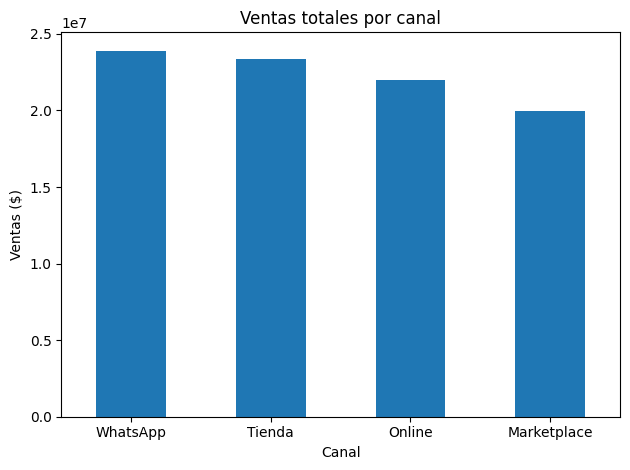

In [209]:
import matplotlib.pyplot as plt

ventas_canal.plot(kind="bar")

plt.title("Ventas totales por canal")
plt.xlabel("Canal")
plt.ylabel("Ventas ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [210]:
ventas_categoria = (
    df_graficos
    .groupby("Categoría")["Total_Venta"]
    .sum()
    .sort_values(ascending=False)
)

ventas_categoria

,Total_Venta
Categoría,
Tecnología,53614295
Hogar,15542761
Belleza,11963040
Deportes,6178011
Oficina,1938958


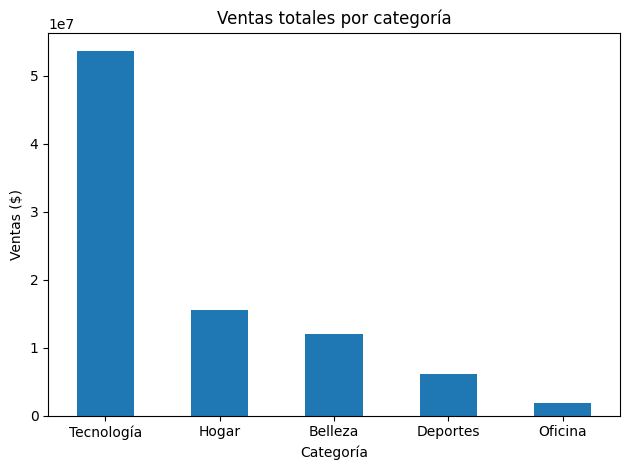

In [211]:
ventas_categoria.plot(kind="bar")

plt.title("Ventas totales por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ventas ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [212]:
ventas_mes = (
    df_graficos.dropna(subset=["Fecha"])
    .groupby(df_graficos.dropna(subset=["Fecha"])["Fecha"].dt.to_period("M"))["Total_Venta"]
    .sum()
)

ventas_mes

,Total_Venta
Fecha,
2024-01,6093806
2024-02,7678790
2024-03,4504415
2024-04,8387780
2024-05,12135351
2024-06,4814948
2024-07,8684935
2024-08,10870430
2024-09,7576616


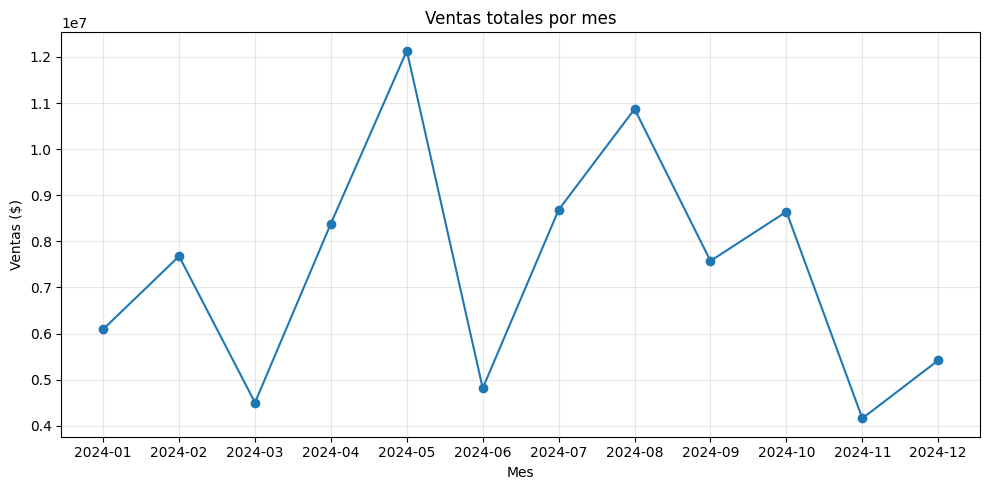

In [213]:
import matplotlib.pyplot as plt

ventas_mes.index = ventas_mes.index.astype(str)

plt.figure(figsize=(10, 5))
plt.plot(ventas_mes.index, ventas_mes.values, marker="o")

plt.title("Ventas totales por mes")
plt.xlabel("Mes")
plt.ylabel("Ventas ($)")
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [214]:
top_productos = (
    df_graficos
    .groupby("Producto")["Total_Venta"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_productos

,Total_Venta
Producto,
Notebook,33427425
Monitor,13505085
Mesa,8166385
Plancha pelo,5330260
Impresora,4457475
Silla,3804877
Perfume,3316369
Mancuernas,2298470
Lámpara,2211340


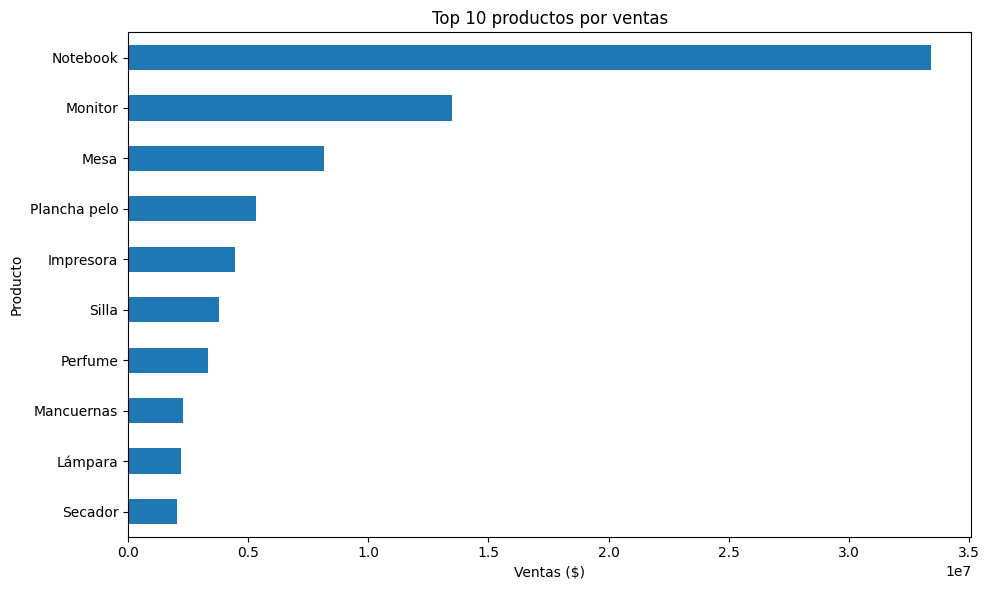

In [215]:
plt.figure(figsize=(10, 6))

top_productos.sort_values().plot(kind="barh")

plt.title("Top 10 productos por ventas")
plt.xlabel("Ventas ($)")
plt.ylabel("Producto")
plt.tight_layout()
plt.show()

In [216]:
df_graficos = df[~df["Dato_Originalmente_Vacio"]].copy()
print(f"\nRegistros totales en dataset: {len(df)}")
print(f"Registros para gráficos (excluidos originalmente vacíos): {len(df_graficos)}")
print(f"Registros excluidos de gráficos: {len(df) - len(df_graficos)}")


Registros totales en dataset: 646
Registros para gráficos (excluidos originalmente vacíos): 634
Registros excluidos de gráficos: 12


## 10. Análisis de las visualizaciones

A partir de las visualizaciones realizadas, se pueden identificar los principales comportamientos de las ventas durante el año 2024.

En relación con los **canales de venta**, WhatsApp presenta el mayor monto de ventas, seguido por Tienda, Marketplace y Online. Los resultados muestran una distribución relativamente cercana entre los cuatro canales.

Por **categoría**, Tecnología concentra la mayor cantidad de ventas, superando ampliamente al resto de las categorías. Le siguen Hogar y Belleza, mientras que Deportes y Oficina presentan montos considerablemente menores.

En la **evolución mensual**, las ventas presentan variaciones a lo largo del año. El mayor nivel de ventas se registra en **mayo**, mientras que noviembre presenta el menor monto. También se observan aumentos importantes durante abril, julio, agosto y octubre.

Finalmente, en el **Top 10 de productos**, Notebook destaca con el mayor monto de ventas, seguido por Monitor y Mesa. Estos productos concentran una parte importante de las ventas dentro del conjunto analizado.

En términos generales, el análisis permite identificar diferencias relevantes entre canales, categorías, períodos y productos, proporcionando una primera visión sobre el comportamiento comercial de la empresa.
